# 02 - Modelo de Classificação

## 1. Objetivo do modelo

Neste notebook será criado o modelo preditivo para classificar se um voo irá atrasar (atraso ≥ 15 min na chegada).

No notebook 01_eda foi realizada a análise exploratória, a seleção das features, o tratamento de formato e a definição do target ARRIVAL_DELAY_CLASS. A manipulação dos dados brutos é feita pelo módulo data_loader.py, criado neste trabalho.

Serão treinados e comparados pelo menos dois algoritmos de classificação. Como a EDA identificou classes desbalanceadas (~81% / ~19%), o modelo será avaliado contra um baseline trivial (acurácia de ~81%) e com métricas adequadas ao desbalanceamento (precision, recall, F1), não apenas acurácia.

## 2. Setup e carga dos dados processados

In [ ]:
# Importando bibliotecas necessárias.
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from src import data_loader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
# Criação do Parquet processado
df = data_loader.load_flights('../data/raw/flights.csv', output_path='../data/processed/flights_class.parquet')

/home/grazzica/ProjetosPosML/Tech_challenge_3/src/data_loader.py:12: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_path)


In [2]:
# Carregamento de parquet - usar se o Parquet já estiver criado!

df = pd.read_parquet('../data/processed/flights_class.parquet')

## 3. Preparação para modelagem

### 3.1 Separação de features (X) e target (y)

In [3]:
#Separação das Features e Target
X = df.drop(columns=['ARRIVAL_DELAY', 'ARRIVAL_DELAY_CLASS'])
y = df['ARRIVAL_DELAY_CLASS']

In [4]:
# Verificação das features
X.columns

Index(['MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'ORIGIN_AIRPORT',
       'DESTINATION_AIRPORT', 'DISTANCE', 'SCHEDULED_DEPARTURE_HOUR',
       'SCHEDULED_DEPARTURE_MINUTE'],
      dtype='str')

In [5]:
X.count()

MONTH                         5231130
DAY                           5231130
DAY_OF_WEEK                   5231130
AIRLINE                       5231130
ORIGIN_AIRPORT                5231130
DESTINATION_AIRPORT           5231130
DISTANCE                      5231130
SCHEDULED_DEPARTURE_HOUR      5231130
SCHEDULED_DEPARTURE_MINUTE    5231130
dtype: int64

In [6]:
# Verificação do Target

y.value_counts()

ARRIVAL_DELAY_CLASS
0    4227770
1    1003360
Name: count, dtype: int64

### 3.2 Encoding das features categóricas (Label Encoding)

In [7]:
# Criação dos Encoders para as features AIRLINE, ORIGIN_AIRPORT, DESTINATION AIRPORT

encoders = {}
for col in ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

In [8]:
# Verificação do Encoding

X.head()

,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DISTANCE,SCHEDULED_DEPARTURE_HOUR,SCHEDULED_DEPARTURE_MINUTE
0,1,1,4,1,17,277,1448,0,5
1,1,1,4,0,176,235,2330,0,10
2,1,1,4,11,278,66,2296,0,20
3,1,1,4,0,176,203,2342,0,20
4,1,1,4,1,277,17,1448,0,25


### 3.3 Split treino/test (estratificado)

In [9]:
# Montanto do Train-Test Split 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Parâmetro stratfy em y serve para manter a proporção do split em função do desbalanceamento de classe (~81% vs ~19%)

In [10]:
#Validação da proporção
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

ARRIVAL_DELAY_CLASS
0    0.808194
1    0.191806
Name: proportion, dtype: float64
ARRIVAL_DELAY_CLASS
0    0.808194
1    0.191806
Name: proportion, dtype: float64


## 4. Modelagem Supervisionada - Classificação

### 4.1 Baseline (modelo trivial para referência)

In [11]:
# Criar o modelo de machine learning com DummyClassifier
# Parâmetro strategy = 'most_frequent faz prever sempre classe majoritária
Baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)

# Treinar o modelo de machine learning
Baseline_model.fit(X_train, y_train)

# Prever com dados de teste

y_pred = Baseline_model.predict(X_test)

In [12]:
# Verificação da performance do modelo

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.8081944054152735


/home/grazzica/ProjetosPosML/Tech_challenge_3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/grazzica/ProjetosPosML/Tech_challenge_3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

           0       0.81      1.00      0.89    845554
           1       0.00      0.00      0.00    200672

    accuracy                           0.81   1046226
   macro avg       0.40      0.50      0.45   1046226
weighted avg       0.65      0.81      0.72   1046226



/home/grazzica/ProjetosPosML/Tech_challenge_3/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Com a analise acima, é possível confirmar que baseline é de ~81%. No Baseline_model confirmamos que o modelo sempre irá prever a classe 0 que é a mais frequente definida no parâmetro __strategy__ (recall= 1). Como nunca preve a classe 1, o recall = 0. 

### 4.2 Modelo 1 - Decision Tree

Para o modelo Decision Tree, é necessário definir a profundidade da árvore que será gerada. Para isso, iremos avaliar numa amosta de 500k linhas para identificar qual seria o melhor valor.

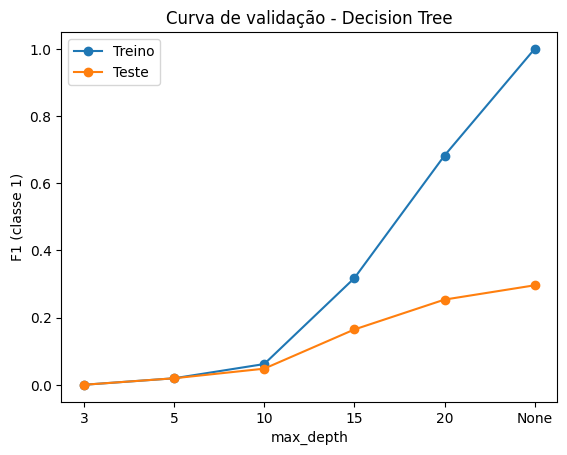

In [13]:
# Amostra estratificada de 500k para a busca 
X_sample = X_train.sample(n=500_000, random_state=42)
y_sample = y_train.loc[X_sample.index]

# Valores de profundidade a testar
depths = [3, 5, 10, 15, 20, None]

# Listas para guardar o F1 da classe 1 em treino e teste
f1_train = []
f1_test = []

for depth in depths:
    # Treina a árvore com a profundidade atual
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_sample, y_sample)

    # Mede F1 da classe 1 no próprio treino (amostra) e no teste
    f1_train.append(f1_score(y_sample, tree.predict(X_sample), pos_label=1))
    f1_test.append(f1_score(y_test, tree.predict(X_test), pos_label=1))

# Plota as duas curvas
labels = [str(d) for d in depths]  # converte None para texto no eixo
plt.plot(labels, f1_train, marker='o', label='Treino')
plt.plot(labels, f1_test, marker='o', label='Teste')
plt.xlabel('max_depth')
plt.ylabel('F1 (classe 1)')
plt.title('Curva de validação - Decision Tree')
plt.legend()
plt.show()

Baseado no teste, pode-se ver que o overfitting começa a ocorrer acima de max_depth=10, o que indicaria que esse seria o melhor valor. Contúdo o F1 da classe 1 é baixíssimo indicando que o modelo não aprende. 
Em suma, esse não seria o modelo mais adequado. 
Para este trabalho vamos trabalhar com profundidade 15 (que tem um f1=~0,16) mesmo sabendo que ocorre overfitting para comparação com o próximo modelo.

In [14]:
# Criar o modelo de machine learning com DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(max_depth= 15, random_state=42)

# Treinar o modelo de machine learning
decision_tree_model.fit(X_train, y_train)

# Prever com dados de teste

y_pred_tree = decision_tree_model.predict(X_test)

In [15]:
#Análise estatistica do modelo

print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.82      0.98      0.89    845554
           1       0.56      0.11      0.18    200672

    accuracy                           0.81   1046226
   macro avg       0.69      0.54      0.54   1046226
weighted avg       0.77      0.81      0.76   1046226



In [21]:
# Criar o modelo de machine learning com DecisionTreeClassifier Balanceado

decision_tree_model_balanced = DecisionTreeClassifier(max_depth= 15, class_weight= 'balanced' ,random_state=42)

# Treinar o modelo de machine learning
decision_tree_model_balanced.fit(X_train, y_train)

# Prever com dados de teste

y_pred_tree_balanced = decision_tree_model_balanced.predict(X_test)

In [22]:
#Análise estatistica do modelo

print(classification_report(y_test, y_pred_tree_balanced))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75    845554
           1       0.30      0.63      0.41    200672

    accuracy                           0.65   1046226
   macro avg       0.59      0.64      0.58   1046226
weighted avg       0.77      0.65      0.69   1046226



Conclusões:
- É possível confirmar que a amostra de 500k dados foi suficiente para representar o modelo na identificação do melhor valor para max_depth visto que o F1 para classe 1 de ~16% é próximo dos 18 encontrados.
- Quando o modelo prevê atraso, acerta 56% das vezes (precisão), contudo captura apenas 11% dos dados reais, ou seja, o modelo supõe atraso poucas vezes, mas quando supõe acerta pouco mais da metade. 
- Comparado com o baseline é possível verificar uma melhoria de performance, mesmo que não seja boa, o que era esperado.
- Sabendo que há um desbalanceamento nas classes, foi criado uma versão do modelo com balanceamento de classes para comparação afim de incentivar o modelo a supor mais atrasos. Comparando o resultado é possível identificar melhora quando comparamos F1 que sobe de 18% para 41% o que significa que, mesmo com uma acuráciea menor, o modelo é capaz de identificar um número maior de atrasos.

### 4.3 Modelo 2 - Random Forest

In [ ]:
# Criar o modelo de machine learning com RandomForestClassifier

random_forest_model = RandomForestClassifier(n_estimators=50, max_depth= 20, n_jobs=4, random_state=42)

# Treinar o modelo de machine learning
random_forest_model.fit(X_train, y_train)

# Prever com dados de teste

y_pred_forest = random_forest_model.predict(X_test)

In [24]:
#Análise estatistica do modelo

print(classification_report(y_test, y_pred_forest))

              precision    recall  f1-score   support

           0       0.82      0.99      0.90    845554
           1       0.71      0.10      0.17    200672

    accuracy                           0.82   1046226
   macro avg       0.77      0.54      0.54   1046226
weighted avg       0.80      0.82      0.76   1046226



In [ ]:
# Criar o modelo de machine learning com RandomForestCLissifier com balanceamento de classes

random_forest_model_balanced = RandomForestClassifier(n_estimators=50, max_depth= 20, n_jobs=4, class_weight= 'balanced', random_state=42)

# Treinar o modelo de machine learning
random_forest_model_balanced.fit(X_train, y_train)

# Prever com dados de teste

y_pred_forest_balanced = random_forest_model_balanced.predict(X_test)

In [19]:
#Análise estatistica do modelo

print(classification_report(y_test, y_pred_forest_balanced))

              precision    recall  f1-score   support

           0       0.88      0.79      0.83    845554
           1       0.38      0.54      0.45    200672

    accuracy                           0.74   1046226
   macro avg       0.63      0.67      0.64   1046226
weighted avg       0.78      0.74      0.76   1046226



Conclusões:
- Houve uma melhoria no modelo random forest não balanceado quando comparado com o decision tree não balanceado apenas em precisão que se dá principalmente por ser um modelo mais robusto. Contudo, Recall e F1 são muito próximos, ou seja, ambos os modelos supõem pouco a classe atraso sendo a razão o desbalanceamento das classes.
- Comparando os modelos com balanceamento, o modelo random forest tem a melhor performance. Assim como ocorreu no modelo decision tree, houve melhora em recall no modelo random forest baanceado (45%) sendo inferior ao modelo decision tree balanceado (63%) mas maior que o random forest não balanceado (10%) e precisão e F1 foram os melhores resultados. 

### 4.4 Comparação dos Modelos

A tabela abaixo compara todos os modelos treinados, com foco nas métricas da classe 1 (atrasos), que é a classe de interesse. A acurácia é apresentada apenas como referência — devido ao desbalanceamento (~81% / ~19%), não é a métrica adequada para avaliar o desempenho real do modelo.

| Modelo | Precision (classe 1) | Recall (classe 1) | F1 (classe 1) | Acurácia |
|:---|:---:|:---:|:---:|:---:|
| Baseline (DummyClassifier) | 0,00 | 0,00 | 0,00 | 0,81 |
| Decision Tree | 0,56 | 0,11 | 0,18 | 0,81 |
| Decision Tree (balanced) | 0,30 | 0,63 | 0,41 | 0,65 |
| Random Forest | 0,71 | 0,10 | 0,17 | 0,82 |
| Random Forest (balanced) | 0,38 | 0,54 | **0,45** | 0,74 |

**Conclusões:**

- Todos os modelos superam o baseline, que é incapaz de identificar qualquer atraso (F1 zero na classe 1).
- Sem tratamento de desbalanceamento, todos os modelos têm recall muito baixo (~0,10): preveem atraso raramente, pois a classe majoritária domina o aprendizado. A precisão é razoável, mas o modelo "perde" quase todos os atrasos reais.
- O tratamento de desbalanceamento (`class_weight='balanced'`) foi o fator de maior impacto: elevou o recall da classe 1 de ~0,10 para a faixa de 0,54–0,63, ao custo de menor precisão e acurácia (trade-off esperado).
- Entre os modelos balanceados, a **Random Forest** apresentou o melhor F1 da classe 1 (0,45) e maior acurácia (0,74), confirmando a vantagem sobre a árvore única.
- A Decision Tree balanceada tem recall maior (0,63), mas precisão e acurácia menores — perfil mais agressivo, com mais alarmes falsos.
- O desempenho absoluto na classe 1 permanece limitado (F1 máximo ~0,45), sugerindo um teto imposto pelas features disponíveis — variáveis conhecidas antes do voo não capturam as causas reais de atraso (clima, manutenção, efeito cascata operacional).


## 6.0 Limitações dos modelos

 - Apesar de o Random Forest balanceado ser o melhor modelo, o F1 de 0,45 indica desempenho limitado em termos absolutos. O modelo captura pouco mais da metade dos atrasos.

 - É possível identificar um problema relacionado ao Teto de Features no qual as features pré-voo não capturam causas reais de atraso como clima, falhas mecânicas de aeronaves, falhas de operações e etc. 

 - Mesmo com o desempenho do Random Forest Balanceado ser o melhor, capturar apenas 54% dos atrasos não seria adequado para ser usado em produção, necessitando ser melhorado.

 - O Balanceamento melhorou o recall mas derrubou a precisão. O ponto ideal entre esses indicadores dependeria do fim para o qual o modelo seria usado. 

 - A superioridade esperada da Random Forest sobre a Decision Tree só se confirmou após o tratamento de desbalanceamento. Nos modelos sem balanceamento, ambas tiveram F1 equivalente (~0,17–0,18), pois o desbalanceamento limitava as duas igualmente. Com class_weight='balanced', a Random Forest superou a árvore única (F1 0,45 vs 0,41), evidenciando a vantagem do ensemble.

 - Limitações de hardware (RAM) restringiram os hiperparâmetros da Random Forest (50 árvores, profundidade máxima 20). Configurações mais robustas poderiam alterar o desempenho e não foram exploradas neste trabalho.

## 7 Próximos passos

- Enriquecer a base de dados original com novas features com maior impacto como clima, congestionamento por horário, feriados e etc. afim de atacar o teto de features

- Seria possível utilizar Latitude e Longitude dos aeroportos para enriquecer o modelo

- Com mais recursos computacionais, testar modelo Random Forest com mais árvores e profundidade e executar modelos mais robustos com maior demanda computacional. 